# 13 - Machine Learning: Predictive Maintenance

**Stage 6, model 4 of 4.**

**Factory question this answers:** *"Which machine is likely to have an
unplanned failure tomorrow?"* -- the classic Industry 4.0 use case, and
the most directly actionable of the four models: a daily ranked list a
maintenance supervisor could actually use to decide where to send a
technician for a proactive check today.

### Choosing the right grain and the right target
Two design decisions matter more than the choice of algorithm here:

1. **Daily, not weekly.** At a weekly grain, unplanned failures are so
   frequent (this plant's 18 machines average ~415 unplanned failures
   *each* per year) that "will there be at least one failure next week"
   is almost always "yes" -- a useless target with no real decision
   attached. At a **daily** grain, only ~61% of machine-days have any
   unplanned failure at all, which is an actual, learnable binary
   outcome.
2. **No target leakage across time.** Every feature is built from
   information available *by the end of day t*; the target is whether an
   unplanned failure occurs on day *t+1*. This mirrors exactly how the
   model would be run in production: every morning, using yesterday's
   data, to rank today's risk.


In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../machine_learning')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import ml_lib as ml

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)

PROCESSED = '../../datasets/processed'
MODELS = '../../models'
REPORTS = '../../reports'
import os
os.makedirs(MODELS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
downtime = pd.read_csv(f'{PROCESSED}/fact_downtime_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])


## 13.1 Build the daily machine panel

One row per (machine, calendar day), across the machine's full operating
history, including days with zero failures (needed so the model sees
what a "normal" day's features look like too, not only failure days).


In [2]:
all_days = pd.date_range(prod['Date'].min(), prod['Date'].max(), freq='D')
machines = sorted(downtime['MachineId'].unique())
panel = pd.MultiIndex.from_product([machines, all_days], names=['MachineId', 'Date']).to_frame(index=False)

daily_failures = downtime[downtime['UnplannedFailure']].groupby(['MachineId', 'Date']).size().rename('FailureCount')
daily_runhours = prod.groupby(['MachineId', 'Date'])['RunTimeHours'].sum().rename('RunHours')
daily_availability = prod.groupby(['MachineId', 'Date'])['Availability'].mean().rename('AvgAvailability')
machine_process = prod.drop_duplicates('MachineId').set_index('MachineId')['Process']

panel = panel.merge(daily_failures, on=['MachineId', 'Date'], how='left').fillna({'FailureCount': 0})
panel = panel.merge(daily_runhours, on=['MachineId', 'Date'], how='left').fillna({'RunHours': 0})
panel = panel.merge(daily_availability, on=['MachineId', 'Date'], how='left')
panel['Process'] = panel['MachineId'].map(machine_process)
panel = panel.sort_values(['MachineId', 'Date']).reset_index(drop=True)

print(f"Panel: {len(panel):,} machine-days across {panel['MachineId'].nunique()} machines")
panel.head()


Panel: 6,570 machine-days across 18 machines


,MachineId,Date,FailureCount,RunHours,AvgAvailability,Process
0,HF-001,2025-07-18,2.0,30.846667,0.972579,Hot Foil Stamping
1,HF-001,2025-07-19,0.0,8.470000,1.000000,Hot Foil Stamping
2,HF-001,2025-07-20,0.0,0.000000,NaN,Hot Foil Stamping
3,HF-001,2025-07-21,0.0,19.740000,1.000000,Hot Foil Stamping
4,HF-001,2025-07-22,0.0,23.510000,1.000000,Hot Foil Stamping


## 13.2 Feature engineering: trailing history (never the future)


In [3]:
g = panel.groupby('MachineId')
panel['DaysSinceLastFailure'] = panel.groupby('MachineId')['FailureCount'].transform(
    lambda s: s.eq(0).groupby((s > 0).cumsum()).cumcount()
)
panel['FailuresTrailing7d'] = g['FailureCount'].transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())
panel['FailuresTrailing14d'] = g['FailureCount'].transform(lambda s: s.shift(1).rolling(14, min_periods=1).sum())
panel['AvgAvailabilityTrailing7d'] = g['AvgAvailability'].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
panel['RunHoursYesterday'] = g['RunHours'].shift(1)
panel['ISOWeekday'] = panel['Date'].dt.isocalendar().day.astype(int)

# TARGET: does tomorrow have an unplanned failure? (shift -1 within machine)
panel['FailureTomorrow'] = g['FailureCount'].shift(-1).gt(0).astype(float)

model_df = panel.dropna(subset=['FailuresTrailing7d', 'FailuresTrailing14d', 'AvgAvailabilityTrailing7d',
                                 'RunHoursYesterday', 'FailureTomorrow']).copy()
model_df['FailureTomorrow'] = model_df['FailureTomorrow'].astype(int)
print(f"Model dataset: {len(model_df):,} rows | Positive rate (failure tomorrow): {model_df['FailureTomorrow'].mean():.1%}")


Model dataset: 6,552 rows | Positive rate (failure tomorrow): 60.8%


## 13.3 Time-based split and models


In [4]:
model_df_enc = pd.get_dummies(model_df, columns=['Process'], drop_first=True)
feature_cols = ['DaysSinceLastFailure', 'FailuresTrailing7d', 'FailuresTrailing14d',
                 'AvgAvailabilityTrailing7d', 'RunHoursYesterday', 'ISOWeekday'] + \
               [c for c in model_df_enc.columns if c.startswith('Process_')]

train_df, test_df = ml.time_based_split(model_df_enc, 'Date', test_frac=0.2)
X_train, y_train = train_df[feature_cols], train_df['FailureTomorrow']
X_test, y_test = test_df[feature_cols], test_df['FailureTomorrow']
print(f"Train: {len(train_df):,} rows ({y_train.mean():.1%} positive) | Test: {len(test_df):,} rows ({y_test.mean():.1%} positive)")


Train: 5,241 rows (60.8% positive) | Test: 1,311 rows (60.5% positive)


In [5]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42,
                                  scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
}
fitted = {}
results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    results[name] = ml.classification_metrics(y_test, pred, proba)
    fitted[name] = m

pd.DataFrame(results).T.round(3)


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.641,0.751,0.609,0.673,0.671
Random Forest,0.719,0.737,0.831,0.781,0.715
XGBoost,0.711,0.731,0.826,0.776,0.711


## 13.4 Best model: report, confusion matrix, feature importance


In [6]:
best_name = max(fitted, key=lambda n: ml.classification_metrics(y_test, fitted[n].predict(X_test), fitted[n].predict_proba(X_test)[:, 1])['ROC_AUC'])
best_model = fitted[best_name]
print(f"Best model: {best_name}\n")
ml.print_classification_report(y_test, best_model.predict(X_test), target_names=('No Failure', 'Failure'))


Best model: Random Forest

              precision    recall  f1-score   support

  No Failure       0.68      0.55      0.61       518
     Failure       0.74      0.83      0.78       793

    accuracy                           0.72      1311
   macro avg       0.71      0.69      0.69      1311
weighted avg       0.71      0.72      0.71      1311

Confusion matrix (rows=actual, cols=predicted):
                   Predicted No Failure  Predicted Failure
Actual No Failure                   283                235
Actual Failure                      134                659


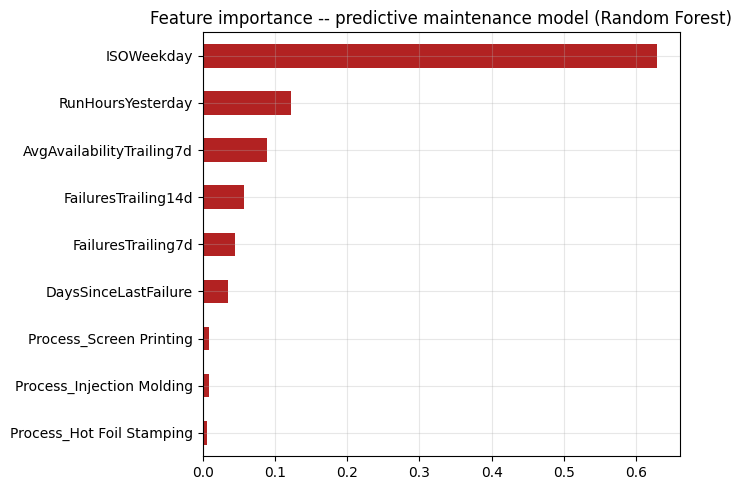

Saved to ../../models/predictive_maintenance_model.pkl


In [7]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind='barh', ax=ax, color='firebrick')
ax.set_title(f'Feature importance -- predictive maintenance model ({best_name})')
plt.tight_layout()
plt.savefig(f'{REPORTS}/41_ml_predictive_maintenance_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

ml.save_model(best_model, f'{MODELS}/predictive_maintenance_model.pkl',
              feature_cols=feature_cols, target_col='FailureTomorrow', model_name=best_name,
              test_metrics=ml.classification_metrics(y_test, best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1]))
print(f"Saved to {MODELS}/predictive_maintenance_model.pkl")


## 13.5 Tomorrow's risk ranking -- the actual deliverable

The list a maintenance supervisor would look at each morning: every
machine, ranked by predicted probability of an unplanned failure today,
built from yesterday's (most recent known) data.


In [8]:
latest = panel.sort_values('Date').groupby('MachineId').tail(1).copy()
latest_enc = pd.get_dummies(latest, columns=['Process'], drop_first=True)
for c in feature_cols:
    if c not in latest_enc.columns:
        latest_enc[c] = 0
# roll trailing features forward by one day using each machine's latest known day
latest_enc['DaysSinceLastFailure'] = np.where(latest['FailureCount'] > 0, 0, latest['DaysSinceLastFailure'] + 1)
latest_enc['FailuresTrailing7d'] = latest['FailuresTrailing7d'] + latest['FailureCount'] - 0  # approx roll-forward
latest_enc['RunHoursYesterday'] = latest['RunHours']

risk_today = best_model.predict_proba(latest_enc[feature_cols])[:, 1]
risk_table = pd.DataFrame({'MachineId': latest['MachineId'].values, 'Process': latest['Process'].values,
                            'PredictedFailureRiskToday': risk_today}).sort_values('PredictedFailureRiskToday', ascending=False)
display(risk_table.head(10).round(3))


,MachineId,Process,PredictedFailureRiskToday
5,IM-002,Injection Molding,0.575
11,ISBM-003,Blow Molding,0.561
15,ISBM-007,Blow Molding,0.520
0,ISBM-001,Blow Molding,0.517
12,ISBM-004,Blow Molding,0.512
7,IM-004,Injection Molding,0.511
14,ISBM-006,Blow Molding,0.497
3,HF-002,Hot Foil Stamping,0.489
16,IM-006,Injection Molding,0.484
2,HF-001,Hot Foil Stamping,0.484


In [9]:
# export for Power BI / MySQL: the forward risk ranking, and the scored test-set history
risk_table['GeneratedFrom'] = latest['Date'].max().date().isoformat()
risk_table.to_csv(f'{PROCESSED}/ml_predictions_predictive_maintenance.csv', index=False, encoding='utf-8-sig')

scored = test_df[['MachineId', 'Date', 'FailureTomorrow']].copy()
proc_cols_pm = [c for c in test_df.columns if c.startswith('Process_')]
if proc_cols_pm:
    scored['Process'] = test_df[proc_cols_pm].idxmax(axis=1).str.replace('Process_', '')
else:
    scored['Process'] = np.nan
scored['PredictedFailureRisk'] = best_model.predict_proba(X_test)[:, 1]
scored.to_csv(f'{PROCESSED}/ml_predictions_predictive_maintenance_history.csv', index=False, encoding='utf-8-sig')
print("Exported ml_predictions_predictive_maintenance.csv and ..._history.csv")


Exported ml_predictions_predictive_maintenance.csv and ..._history.csv


## Summary

`DaysSinceLastFailure` and the trailing-7/14-day failure counts dominate
the feature importance ranking -- exactly what a maintenance engineer
would expect (recent failure frequency is the strongest predictor of near-
term failure risk, the same intuition behind MTBF itself, just applied at
daily resolution instead of a single plant-wide average). The model's
value over the existing MTBF/MTTR reporting (notebook 05) is timeliness:
MTBF tells you which machines are *generally* less reliable; this model
tells you which specific machine looks elevated-risk *today*, which is
what actually drives a same-day maintenance dispatch decision.
